<a href="https://colab.research.google.com/github/Tahasufyan/FirstModel/blob/main/Detectree2_FD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting Env and Idep

# CHECK GPU FIRST (run before anything else)

CHECK GPU FIRST (run before anything else)

In [1]:
import torch
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("CUDA version    :", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print("VRAM            :", round(vram, 1), "GB")
else:
    print("⚠️  NO GPU — go to Runtime → Change runtime type → A100 GPU")

PyTorch version : 2.10.0+cpu
CUDA available  : False
CUDA version    : None
⚠️  NO GPU — go to Runtime → Change runtime type → A100 GPU


INSTALL SYSTEM DEPENDENCIES (GDAL and build tools)

In [2]:
%%bash
apt-get update -qq
apt-get install -y -qq \
    gdal-bin \
    libgdal-dev \
    libspatialindex-dev \
    python3-rtree \
    build-essential \
    cmake \
    ninja-build \
    git
echo "✅ System deps installed"

Selecting previously unselected package python3-numpy.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-python3-numpy_1%3a1.21.5-1ubuntu22.04.1_amd64.deb ...
Unpacking python3-numpy (1:1.21.5-1ubuntu22.04.1) ...
Selecting previously unselected package python3-gdal.
Preparing to unpack .../01-python3-gdal_3.8.4+dfsg-1~jammy0_amd64.deb ...
Unpacking python3-gdal (3.8.4+dfsg-1~jammy0) ...
Selecting previously unselected package gdal-bin.
Preparing to unpack .../02-gdal-bin_3.8.4+dfsg-1~jammy0_amd64.deb ...
Unpacking gdal-bin (3.8.4+dfsg-1~jammy0) ...
Selecting previously unselected package javascript-common.
Preparing to unpack .../03-javascript-common_11+nmu1_all.deb ...
Unpacking javascript-common (11+nmu1) ...
Selecting previously unselected package libjs-underscore.
Preparing to unpack .../04-libjs-underscore_1.13.2~dfsg-2_all.deb ...
Unpacking libjs-underscore (1.13.2~dfsg-2) ...
Selecting previously unselected package libjs-sphinxdo

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


SET GDAL VERSION ENVIRONMENT VARIABLE
Required before installing Python GDAL

In [3]:
import subprocess
gdal_version = subprocess.check_output(['gdal-config', '--version']).decode().strip()
print("System GDAL version:", gdal_version)

import os
os.environ['GDAL_VERSION'] = gdal_version
print("GDAL_VERSION set to:", os.environ['GDAL_VERSION'])

System GDAL version: 3.8.4
GDAL_VERSION set to: 3.8.4


INSTALL PYTHON PACKAGES Order matters: GDAL before rasterio, detectron2 before detectree2

In [4]:
%%bash
# Core geospatial stack
pip install -q gdal==$(gdal-config --version)
pip install -q rasterio
pip install -q geopandas
pip install -q shapely
pip install -q pyproj
pip install -q fiona

# Scientific stack
pip install -q numpy pandas matplotlib scipy scikit-learn

# OpenCV (needed by detectron2)
pip install -q opencv-python-headless

# Detectron2 — built from source to match current Colab PyTorch/CUDA
pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

# detectree2 — install last (depends on detectron2)
pip install -q detectree2

echo "✅ All Python packages installed"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 17.5 MB/s eta 0:00:00
✅ All Python packages installed


RESTART RUNTIME (REQUIRED after installs)

In [ ]:
import os
os.kill(os.getpid(), 9)

MOUNT GOOGLE DRIVE (run after restart)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


VERIFY FULL ENVIRONMENT

In [ ]:
import sys
import torch
import rasterio
import geopandas as gpd
import numpy as np

print("=" * 55)
print("ENVIRONMENT VERIFICATION")
print("=" * 55)

# GPU
print(f"\n{'GPU':}")
print(f"  CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU name       : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM           : {round(vram, 1)} GB")
    print(f"  PyTorch        : {torch.__version__}")
    print(f"  CUDA version   : {torch.version.cuda}")

# Packages
print(f"\nPackages:")
packages = {
    'torch':         torch.__version__,
    'rasterio':      rasterio.__version__,
    'geopandas':     gpd.__version__,
    'numpy':         np.__version__,
}

for pkg, ver in packages.items():
    print(f"  {pkg:<20}: {ver}")

# detectron2
try:
    import detectron2
    print(f"  {'detectron2':<20}: {detectron2.__version__} ✅")
except ImportError:
    print(f"  {'detectron2':<20}: ❌ NOT INSTALLED — rerun Cell 4")

# detectree2
try:
    import detectree2
    print(f"  {'detectree2':<20}: installed ✅")
except ImportError:
    print(f"  {'detectree2':<20}: ❌ NOT INSTALLED — rerun Cell 4")

# GDAL
try:
    from osgeo import gdal
    print(f"  {'GDAL':<20}: {gdal.__version__} ✅")
except ImportError:
    print(f"  {'GDAL':<20}: ❌ NOT INSTALLED")

# Drive
import os
drive_path = '/content/drive/MyDrive/data_ITCD'
if os.path.exists(drive_path):
    print(f"\nGoogle Drive  : ✅ Mounted")
    print(f"data_ITCD     : ✅ Found at {drive_path}")
    folders = [f for f in os.listdir(drive_path) if os.path.isdir(os.path.join(drive_path, f))]
    print(f"Subfolders    : {folders}")
else:
    print(f"\nGoogle Drive  : ❌ NOT MOUNTED or data_ITCD not found")
    print(f"  Run Cell 6 first, then check path: {drive_path}")

print("\n" + "=" * 55)
print("If all ✅ above — ready to tile and train")
print("=" * 55)

ENVIRONMENT VERIFICATION

GPU
  CUDA available : True
  GPU name       : NVIDIA A100-SXM4-80GB
  VRAM           : 85.1 GB
  PyTorch        : 2.10.0+cu128
  CUDA version   : 12.8

Packages:
  torch               : 2.10.0+cu128
  rasterio            : 1.5.0
  geopandas           : 1.1.3
  numpy               : 2.0.2
  detectron2          : 0.6 ✅
  detectree2          : installed ✅
  GDAL                : 3.8.4 ✅

Google Drive  : ✅ Mounted
data_ITCD     : ✅ Found at /content/drive/MyDrive/data_ITCD
Subfolders    : ['EXP_1RGB(rawGSD)', 'EXP_2RGB(5cmGSD)']

If all ✅ above — ready to tile and train


INSPECT ALL DATA IN data_ITCD

In [ ]:
import os
import rasterio
import geopandas as gpd
from pathlib import Path

base = '/content/drive/MyDrive/data_ITCD'

RASTER_EXT = ['.tif', '.tiff']
VECTOR_EXT = ['.gpkg', '.shp', '.geojson']

print("=" * 65)
print("DATA INSPECTION — data_ITCD")
print("=" * 65)

total_r = 0
total_v = 0

for exp_folder in sorted(os.listdir(base)):
    exp_path = os.path.join(base, exp_folder)
    if not os.path.isdir(exp_path):
        continue

    print(f"\n{'━'*65}")
    print(f"EXPERIMENT: {exp_folder}")
    print(f"{'━'*65}")

    for root, dirs, files in os.walk(exp_path):
        # Skip tile folders
        if 'tile' in root.lower():
            continue

        rasters = [f for f in files if Path(f).suffix.lower() in RASTER_EXT]
        vectors = [f for f in files if Path(f).suffix.lower() in VECTOR_EXT]

        if not rasters and not vectors:
            continue

        rel = os.path.relpath(root, base)
        print(f"\n  📁 {rel}")

        for fname in sorted(rasters):
            fpath = os.path.join(root, fname)
            total_r += 1
            try:
                with rasterio.open(fpath) as src:
                    epsg    = src.crs.to_epsg() if src.crs else None
                    gsd_cm  = round(src.res[0] * 100, 2)
                    bands   = src.count
                    w, h    = src.width, src.height
                    size_mb = round(os.path.getsize(fpath) / 1024 / 1024, 1)
                    utm_ok  = "✅ UTM" if epsg and 32600 <= epsg <= 32800 else f"❌ EPSG:{epsg}"
                print(f"    [RASTER] {fname}")
                print(f"             {utm_ok} | GSD:{gsd_cm}cm | {bands}band | {w}x{h}px | {size_mb}MB")
            except Exception as e:
                print(f"    [RASTER] {fname} — ❌ ERROR: {e}")

        for fname in sorted(vectors):
            fpath = os.path.join(root, fname)
            total_v += 1
            try:
                gdf    = gpd.read_file(fpath)
                epsg   = gdf.crs.to_epsg() if gdf.crs else None
                utm_ok = "✅ UTM" if epsg and 32600 <= epsg <= 32800 else f"❌ EPSG:{epsg}"
                size_mb = round(os.path.getsize(fpath) / 1024 / 1024, 1)
                print(f"    [VECTOR] {fname}")
                print(f"             {utm_ok} | {len(gdf)} features | {size_mb}MB")
            except Exception as e:
                print(f"    [VECTOR] {fname} — ❌ ERROR: {e}")

print(f"\n{'='*65}")
print(f"Total rasters : {total_r}")
print(f"Total vectors : {total_v}")
print(f"{'='*65}")

DATA INSPECTION — data_ITCD

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPERIMENT: EXP_1RGB(rawGSD)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📁 EXP_1RGB(rawGSD)/Johor/01_Johor
    [VECTOR] Johor_01_UTM.gpkg
             ✅ UTM | 1 features | 0.1MB

  📁 EXP_1RGB(rawGSD)/Johor/01_Johor/Atrributes
    [VECTOR] 01_Johor_crowns_UTM.gpkg
             ✅ UTM | 475 features | 0.4MB
    [VECTOR] CA_Johor_01_UTM.gpkg
             ✅ UTM | 475 features | 0.4MB

  📁 EXP_1RGB(rawGSD)/Johor/01_Johor/Rastered_Data
    [RASTER] ORTHORGB_MATANG_0_UTM.tif
             ✅ UTM | GSD:2.5cm | 3band | 15752x17169px | 801.8MB

  📁 EXP_1RGB(rawGSD)/Johor/03_Johor
    [VECTOR] 02_Pahang_UTM.gpkg
             ✅ UTM | 0 features | 0.1MB
    [VECTOR] 03_Johor_UTM.gpkg
             ✅ UTM | 1 features | 0.1MB

  📁 EXP_1RGB(rawGSD)/Johor/03_Johor/Atrributes
    [VECTOR] 03_Johor_crowns_UTM.gpkg
             ✅ UTM | 579 features | 0.6MB


KeyboardInterrupt: 

# Tiling of Raw RGB ortho image
Data of Ortho and it is own Shapefile aready reproject in Reproject to UTM local for malaysia in pycharm  in data preparatin process


###  Tiling Johor Sites

In [ ]:

from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

# ══════════════════════════════════════════════════════════════════════════
# TILING — JOHOR — EXP_1RGB(rawGSD)
# Sites: 01_Johor (TRAIN), 02_Johor (TEST), 03_Johor (TRAIN)
# GSD: 2.5cm | Parameters: buffer=5, tile=15x15m
# Note: folder name typo is "Atrributes" — preserved exactly
# ══════════════════════════════════════════════════════════════════════════

johor_base = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Johor'

sites = {
    '01_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_0_UTM.tif',
        'crown': 'Atrributes/01_Johor_crowns_UTM.gpkg',
        'role':  'train'
    },
    '02_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_02_UTM.tif',
        'crown': 'Atrributes/02_Johor_crowns_UTM.gpkg',
        'role':  'test'
    },
    '03_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_03_UTM.tif',
        'crown': 'Atrributes/03_Johor_crowns_UTM.gpkg',
        'role':  'train'
    },
}

for site_name, info in sites.items():
    print(f"\n{'='*55}")
    print(f"JOHOR — {site_name} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{johor_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    # Verify files exist
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown file not found: {crown_path}")
        continue

    # Fix geometries
    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns loaded: {len(crowns)} valid polygons")

    # Clean and create output folder
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    # Tile
    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 5,
        tile_width           = 15,
        tile_height          = 15,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    # Count output
    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ Tiles created: {n_png} PNG | {n_json} GeoJSON")

    # Train/val split
    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)

    if info['role'] == 'train':
        print(f"✅ Split done — TRAIN site (used in training)")
    else:
        print(f"✅ Split done — TEST site (NOT used in training, kept for final evaluation only)")

print(f"\n{'='*55}")
print("JOHOR TILING COMPLETE")
print(f"{'='*55}")


JOHOR — 01_Johor (TRAIN)
✅ Crowns loaded: 475 valid polygons


  0%|          | 0/482 [00:00<?, ?it/s]

✅ Tiles created: 455 PNG | 455 GeoJSON
✅ Split done — TRAIN site (used in training)

JOHOR — 02_Johor (TEST)
✅ Crowns loaded: 333 valid polygons


  0%|          | 0/298 [00:00<?, ?it/s]

✅ Tiles created: 293 PNG | 293 GeoJSON
✅ Split done — TEST site (NOT used in training, kept for final evaluation only)

JOHOR — 03_Johor (TRAIN)
✅ Crowns loaded: 579 valid polygons


  0%|          | 0/534 [00:00<?, ?it/s]

✅ Tiles created: 534 PNG | 534 GeoJSON
✅ Split done — TRAIN site (used in training)

JOHOR TILING COMPLETE


### Tiling Pahang Sites

In [ ]:
from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

# ══════════════════════════════════════════════════════════════════════════
# TILING — PAHANG — EXP_1RGB(rawGSD)
# Sites: 01_Pahang (TRAIN), 02_Pahang (TEST), 03_Pahang (TRAIN)
# GSD: 4.3cm | Parameters: buffer=10, tile=30x30m
# CRITICAL: 01_Pahang has TRAILING SPACE in folder name — preserved exactly
# ══════════════════════════════════════════════════════════════════════════

pahang_base = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Pahang'

sites = {
    '01_Pahang ': {             # trailing space — DO NOT REMOVE
        'img':   'Rastered_Data/Ortho_Pahang_01_UTM.tif',
        'crown': 'Attributes/01_Pahang_crowns_UTM.gpkg',
        'role':  'train'
    },
    '02_Pahang': {
        'img':   'Rastered_Data/ORTHORGB_Pahang_02_UTM.tif',
        'crown': 'Attributes/02_Pahang_crowns_UTM.gpkg',
        'role':  'test'
    },
    '03_Pahang': {
        'img':   'Rastered_Data/ORTHORGB_Pahang_03_UTM.tif',
        'crown': 'Attributes/03_Pahang_crowns_UTM.gpkg',
        'role':  'train'
    },
}

for site_name, info in sites.items():
    print(f"\n{'='*55}")
    print(f"PAHANG — {site_name.strip()} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{pahang_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    # Verify files exist
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown file not found: {crown_path}")
        continue

    # Fix geometries
    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns loaded: {len(crowns)} valid polygons")

    # Clean and create output folder
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    # Tile — Pahang uses larger tiles (30x30m) due to 4.3cm GSD and larger crowns
    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 10,
        tile_width           = 30,
        tile_height          = 30,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    # Count output
    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ Tiles created: {n_png} PNG | {n_json} GeoJSON")

    # Train/val split
    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)

    if info['role'] == 'train':
        print(f"✅ Split done — TRAIN site (used in training)")
    else:
        print(f"✅ Split done — TEST site (NOT used in training, kept for final evaluation only)")

print(f"\n{'='*55}")
print("PAHANG TILING COMPLETE")
print(f"{'='*55}")


PAHANG — 01_Pahang (TRAIN)
✅ Crowns loaded: 561 valid polygons


  0%|          | 0/130 [00:00<?, ?it/s]

✅ Tiles created: 129 PNG | 129 GeoJSON
✅ Split done — TRAIN site (used in training)

PAHANG — 02_Pahang (TEST)
✅ Crowns loaded: 306 valid polygons


  0%|          | 0/102 [00:00<?, ?it/s]

✅ Tiles created: 98 PNG | 98 GeoJSON
✅ Split done — TEST site (NOT used in training, kept for final evaluation only)

PAHANG — 03_Pahang (TRAIN)
✅ Crowns loaded: 373 valid polygons


  0%|          | 0/112 [00:00<?, ?it/s]

✅ Tiles created: 112 PNG | 112 GeoJSON
✅ Split done — TRAIN site (used in training)

PAHANG TILING COMPLETE


### Tiling Melaka Sites

In [ ]:
from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

# ══════════════════════════════════════════════════════════════════════════
# TILING — MELAKA — EXP_1RGB(rawGSD)
# Sites: 01_Melaka (TRAIN), 02_Melaka (TEST)
# GSD: 01_Melaka=3.0cm | 02_Melaka=1.68cm
# Parameters: buffer=5, tile=15x15m
# Note: 02_Melaka image filename has a space: "ORTHO MKF1_RGB_UTM.tif"
# ══════════════════════════════════════════════════════════════════════════

melaka_base = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Melaka'

sites = {
    '01_Melaka': {
        'img':   'Rastered_Data/MKF2_RGB_UTM.tif',
        'crown': 'Attributes/01_Melaka_crowns_UTM.gpkg',
        'role':  'train'
    },
    '02_Melaka': {
        'img':   'Rastered_Data/ORTHO MKF1_RGB_UTM.tif',   # space in filename — preserved
        'crown': 'Attributes/02_Melaka_crowns_UTM.gpkg',
        'role':  'test'
    },
}

for site_name, info in sites.items():
    print(f"\n{'='*55}")
    print(f"MELAKA — {site_name} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{melaka_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    # Verify files exist
    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown file not found: {crown_path}")
        continue

    # Fix geometries
    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns loaded: {len(crowns)} valid polygons")

    # Clean and create output folder
    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    # Tile
    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 5,
        tile_width           = 15,
        tile_height          = 15,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    # Count output
    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ Tiles created: {n_png} PNG | {n_json} GeoJSON")

    # Train/val split
    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)

    if info['role'] == 'train':
        print(f"✅ Split done — TRAIN site (used in training)")
    else:
        print(f"✅ Split done — TEST site (NOT used in training, kept for final evaluation only)")

print(f"\n{'='*55}")
print("MELAKA TILING COMPLETE")
print(f"{'='*55}")


MELAKA — 01_Melaka (TRAIN)
✅ Crowns loaded: 276 valid polygons


  0%|          | 0/192 [00:00<?, ?it/s]

✅ Tiles created: 192 PNG | 192 GeoJSON
✅ Split done — TRAIN site (used in training)

MELAKA — 02_Melaka (TEST)
✅ Crowns loaded: 370 valid polygons


  0%|          | 0/314 [00:00<?, ?it/s]

✅ Tiles created: 310 PNG | 310 GeoJSON
✅ Split done — TEST site (NOT used in training, kept for final evaluation only)

MELAKA TILING COMPLETE


# Verify tiles number

In [ ]:
import os
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════
# TILE VERIFICATION — EXP_1RGB(rawGSD)
# Counts all tiles per site and checks train/val/test folder structure
# ══════════════════════════════════════════════════════════════════════════

base = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'

states = ['Johor', 'Melaka', 'Pahang']

print("=" * 65)
print("TILE VERIFICATION REPORT — EXP_1RGB(rawGSD)")
print("=" * 65)

total_png   = 0
total_json  = 0
all_ok      = True

for state in states:
    state_path = os.path.join(base, state)
    if not os.path.isdir(state_path):
        print(f"\n❌ State folder not found: {state}")
        continue

    print(f"\n{'━'*65}")
    print(f"STATE: {state.upper()}")
    print(f"{'━'*65}")

    for site in sorted(os.listdir(state_path)):
        site_path = os.path.join(state_path, site)
        if not os.path.isdir(site_path):
            continue

        tiles_path = os.path.join(site_path, 'tiles')
        if not os.path.exists(tiles_path):
            print(f"\n  ❌ {site.strip()} — NO TILES FOLDER FOUND")
            all_ok = False
            continue

        # Count all files in tiles root
        all_files = os.listdir(tiles_path)
        n_png_root  = len([f for f in all_files if f.endswith('.png')])
        n_json_root = len([f for f in all_files if f.endswith('.geojson')])

        # Count train folder
        train_path = os.path.join(tiles_path, 'train')
        n_png_train  = 0
        n_json_train = 0
        train_folds  = {}
        if os.path.exists(train_path):
            for fold in sorted(os.listdir(train_path)):
                fold_path = os.path.join(train_path, fold)
                if os.path.isdir(fold_path):
                    fold_pngs  = len([f for f in os.listdir(fold_path) if f.endswith('.png')])
                    fold_jsons = len([f for f in os.listdir(fold_path) if f.endswith('.geojson')])
                    train_folds[fold] = (fold_pngs, fold_jsons)
                    n_png_train  += fold_pngs
                    n_json_train += fold_jsons

        # Count test folder
        test_path = os.path.join(tiles_path, 'test')
        n_png_test  = 0
        n_json_test = 0
        if os.path.exists(test_path):
            test_files  = os.listdir(test_path)
            n_png_test  = len([f for f in test_files if f.endswith('.png')])
            n_json_test = len([f for f in test_files if f.endswith('.geojson')])

        total_png  += n_png_root
        total_json += n_json_root

        print(f"\n  SITE: {site.strip()}")
        print(f"    Tiles root   : {n_png_root} PNG | {n_json_root} GeoJSON")
        print(f"    Train folder : {n_png_train} PNG | {n_json_train} GeoJSON")
        if train_folds:
            for fold, (p, j) in train_folds.items():
                print(f"      {fold:<12}: {p} PNG | {j} GeoJSON")
        print(f"    Test folder  : {n_png_test} PNG | {n_json_test} GeoJSON")

        # Check if split was done
        if n_png_train == 0 and n_png_test == 0:
            print(f"    ⚠️  WARNING: train/test folders empty — split may not have run")
            all_ok = False
        else:
            print(f"    ✅ Split confirmed")

print(f"\n{'='*65}")
print(f"TOTAL tiles in root folders : {total_png} PNG | {total_json} GeoJSON")
print()
if all_ok:
    print("✅ ALL SITES VERIFIED — ready to register and train")
else:
    print("⚠️  SOME ISSUES FOUND — check warnings above")
print("=" * 65)

TILE VERIFICATION REPORT — EXP_1RGB(rawGSD)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STATE: JOHOR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SITE: 01_Johor
    Tiles root   : 455 PNG | 455 GeoJSON
    Train folder : 0 PNG | 455 GeoJSON
      fold_1      : 0 PNG | 91 GeoJSON
      fold_2      : 0 PNG | 91 GeoJSON
      fold_3      : 0 PNG | 91 GeoJSON
      fold_4      : 0 PNG | 91 GeoJSON
      fold_5      : 0 PNG | 91 GeoJSON
    Test folder  : 0 PNG | 0 GeoJSON
    ⚠️  WARNING: train/test folders empty — split may not have run

  SITE: 02_Johor
    Tiles root   : 293 PNG | 293 GeoJSON
    Train folder : 0 PNG | 293 GeoJSON
      fold_1      : 0 PNG | 59 GeoJSON
      fold_2      : 0 PNG | 59 GeoJSON
      fold_3      : 0 PNG | 59 GeoJSON
      fold_4      : 0 PNG | 58 GeoJSON
      fold_5      : 0 PNG | 58 GeoJSON
    Test folder  : 0 PNG | 0 GeoJSON
    ⚠️  WARNING: train/test folders empty — split may not have run

  SITE: 03_Joho

# Register and Train

In [ ]:
import os
import time
from detectree2.models.train import register_train_data, setup_cfg, MyTrainer

# ══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1 — RGB RAW — FINAL TRAINING — COLAB A100
# Decisions derived from comparing Gemini, ChatGPT, Perplexity, Claude
# and cross-referencing official detectree2 tutorial by James Ball
# ══════════════════════════════════════════════════════════════════════════

base    = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
out_dir = f'{base}/train_outputs'
os.makedirs(out_dir, exist_ok=True)

# ── Weights ────────────────────────────────────────────────────────────────
trained_model = f'{base}/Weights/model_1.pth'
if not os.path.exists(trained_model):
    raise FileNotFoundError(f"Weights not found: {trained_model}")
print(f"Starting from: {trained_model}")

# ══════════════════════════════════════════════════════════════════════════
# REGISTER — same proven oversampling strategy
# Melaka x3, Johor_01 x1, Johor_03 x2, Pahang_01 x2, Pahang_03 x2
# 02_* sites excluded — sacred test sites never used in training
# ══════════════════════════════════════════════════════════════════════════

register_train_data(f'{base}/Melaka/01_Melaka/tiles/train',  'Melaka_01_a', val_fold=5)
register_train_data(f'{base}/Melaka/01_Melaka/tiles/train',  'Melaka_01_b', val_fold=5)
register_train_data(f'{base}/Melaka/01_Melaka/tiles/train',  'Melaka_01_c', val_fold=5)
register_train_data(f'{base}/Johor/01_Johor/tiles/train',    'Johor_01',    val_fold=5)
register_train_data(f'{base}/Johor/03_Johor/tiles/train',    'Johor_03_a',  val_fold=5)
register_train_data(f'{base}/Johor/03_Johor/tiles/train',    'Johor_03_b',  val_fold=5)
register_train_data(f'{base}/Pahang/01_Pahang /tiles/train', 'Pahang_01_a', val_fold=5)
register_train_data(f'{base}/Pahang/01_Pahang /tiles/train', 'Pahang_01_b', val_fold=5)
register_train_data(f'{base}/Pahang/03_Pahang/tiles/train',  'Pahang_03_a', val_fold=5)
register_train_data(f'{base}/Pahang/03_Pahang/tiles/train',  'Pahang_03_b', val_fold=5)

print("All training sites registered")

trains = (
    "Melaka_01_a_train", "Melaka_01_b_train", "Melaka_01_c_train",
    "Johor_01_train",
    "Johor_03_a_train",  "Johor_03_b_train",
    "Pahang_01_a_train", "Pahang_01_b_train",
    "Pahang_03_a_train", "Pahang_03_b_train",
)

# Melaka_01_a_val MUST be first — controls early stopping
tests = (
    "Melaka_01_a_val",
    "Johor_01_val",
    "Johor_03_a_val",
    "Pahang_01_a_val",
    "Pahang_03_a_val",
)

# ══════════════════════════════════════════════════════════════════════════
# SETUP_CFG — pass parameters through the official API where possible
#
# DECISION: Do NOT override LR manually
#   James Ball's setup_cfg has its own tuned defaults.
#   Previous experiments at LR 0.0001 (Phase 2) failed.
#   0.00005 was too slow. 0.00025 is reasonable.
#   We let setup_cfg set its default and only change what is proven necessary.
#
# DECISION: workers=2 (Perplexity + ChatGPT agree)
#   Enough to keep A100 GPU fed. More than 2 risks memory issues.
#
# DECISION: max_iter=3000 (James's tutorial + all others agree)
#   On A100 this is ~15 minutes. Plenty for convergence.
# ══════════════════════════════════════════════════════════════════════════

base_model = "COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"

cfg = setup_cfg(
    base_model,
    trains,
    tests,
    trained_model,
    workers     = 2,
    eval_period = 100,
    max_iter    = 3000,
    out_dir     = out_dir,
)

# ══════════════════════════════════════════════════════════════════════════
# POST-SETUP OVERRIDES
# Only change what setup_cfg does not expose and what is proven necessary
# ══════════════════════════════════════════════════════════════════════════

# GPU
cfg.MODEL.DEVICE = "cuda"

# Batch size — A100 80GB handles 4 safely, speeds up training
cfg.SOLVER.IMS_PER_BATCH = 4

# ── ANCHOR — minimal safe change ──────────────────────────────────────────
# PROBLEM: Default Level 1 anchor = 32px
#   Your smallest crowns:
#   0.2m² at 4.3cm GSD = 12px — missed entirely
#   0.5m² at 4.3cm GSD = 19px — missed entirely
#   0.5m² at 2.5cm GSD = 20px — barely at boundary
#
# ── ANCHOR STRATEGY: The "Bridge" Solution ───────────────────────────────
# Level 1 (P2): (16, 32) -> Catches 11px (Pahang small) to 45px (Johor medium)
# Level 2 (P3): (64,)    -> Catches managed row trees
# Level 3 (P4): (128,)   -> Catches mature crowns
# Level 4 (P5): (256,)   -> Catches large plantation trees
# Level 5 (P6): (512,)   -> Catches massive 90m2 giants
#
# No 8px = No grass noise.
# No dead zone = Seamless detection across 2.5cm to 4.3cm GSD.
cfg.MODEL.RPN.ANCHOR_SIZES = ((16, 32), (64,), (128,), (256,), (512,))

# Aspect ratios remain at 5 to handle round/organic crown shapes
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [[0.5, 0.75, 1.0, 1.33, 2.0]]

# ── IOU THRESHOLDS — all 4 models agree this is critical ─────────────────
# Default [0.5, 0.7]: requires 70%+ overlap to be positive — too strict
# Small crowns in Pahang/Johor grass often achieve only 40-60% overlap
# [0.4, 0.5]: 50%+ = positive, 40-50% = neutral, <40% = background
# IOU_LABELS MUST accompany IOU_THRESHOLDS — 3 thresholds need 3 labels
cfg.MODEL.ROI_HEADS.IOU_THRESHOLDS = [0.4, 0.5]
cfg.MODEL.ROI_HEADS.IOU_LABELS     = [0, -1, 1]

# ── POSITIVE FRACTION — all 4 models agree ───────────────────────────────
# Default 0.25 = only 128 of 512 ROIs per image are tree examples
# 0.5 = 256 tree ROIs per image — directly improves recall
cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION    = 0.5
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512

# Detections per image — default 100 too low for dense Pahang tiles
cfg.TEST.DETECTIONS_PER_IMAGE = 300

# ── Print summary ──────────────────────────────────────────────────────────
print("\\n" + "=" * 60)
print("EXP1 RGB RAW — FINAL CONFIG")
print("=" * 60)
print(f"Device             : {cfg.MODEL.DEVICE}")
print(f"Weights            : {os.path.basename(trained_model)}")
print(f"Max iterations     : {cfg.SOLVER.MAX_ITER}")
print(f"Batch size         : {cfg.SOLVER.IMS_PER_BATCH}")
print(f"LR                 : {cfg.SOLVER.BASE_LR}  (setup_cfg default)")
print(f"Anchors            : {cfg.MODEL.RPN.ANCHOR_SIZES}")
print(f"  Level 1          : 16px  (was 32px — catches 19px tiny crowns)")
print(f"  Level 2-5        : default unchanged")
print(f"Aspect ratios      : {cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS}")
print(f"IOU_THRESHOLDS     : {cfg.MODEL.ROI_HEADS.IOU_THRESHOLDS}")
print(f"IOU_LABELS         : {cfg.MODEL.ROI_HEADS.IOU_LABELS}")
print(f"POSITIVE_FRACTION  : {cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION}")
print(f"Detections/image   : {cfg.TEST.DETECTIONS_PER_IMAGE}")
print(f"Output dir         : {out_dir}")
print()
print("AUGMENTATIONS: handled automatically by detectree2")
print("LAYER FREEZING: stem + res2 applied after trainer init")
print("=" * 60 + "\\n")

# ══════════════════════════════════════════════════════════════════════════
# TRAIN with layer freezing
# Official detectree2 advanced tutorial technique
# Freeze stem + res2 to prevent overfitting on limited data (~2500 tiles)
# All higher layers + heads remain trainable
# ══════════════════════════════════════════════════════════════════════════

start_time = time.time()

trainer = MyTrainer(cfg, patience=12)
trainer.resume_or_load(resume=False)

# Apply layer freezing AFTER resume_or_load
# Freeze backbone stem — preserves basic edge/texture detectors
trainer.model.backbone.bottom_up.stem.freeze()
# Freeze res2 — preserves low-level shape detectors
for block in trainer.model.backbone.bottom_up.stages[0].children():
    block.freeze()

print("Frozen : stem + res2")
print("Trainable: res3, res4, res5, FPN, RPN, ROI heads")
print("Starting training...\\n")

trainer.train()

# ── Summary ────────────────────────────────────────────────────────────────
elapsed = time.time() - start_time
h = int(elapsed // 3600)
m = int((elapsed % 3600) // 60)
s = int(elapsed % 60)

print(f"\\n{'='*60}")
print("TRAINING COMPLETE")
print(f"Total time : {h}h {m}m {s}s")
print(f"{'='*60}")

print("\\nCheckpoints saved:")
for f in sorted(os.listdir(out_dir)):
    if f.endswith('.pth'):
        mb = os.path.getsize(os.path.join(out_dir, f)) / 1024 / 1024
        print(f"  {f}  ({round(mb)} MB)")

print("\\nNEXT: paste iteration metrics here for analysis")
print("Then run predictions on: 02_Melaka, 02_Johor, 02_Pahang")

Starting from: /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Weights/model_1.pth
All training sites registered
\n============================================================
EXP1 RGB RAW — FINAL CONFIG
Device             : cuda
Weights            : model_1.pth
Max iterations     : 3000
Batch size         : 4
LR                 : 0.0003389  (setup_cfg default)
Anchors            : ((16, 32), (64,), (128,), (256,), (512,))
  Level 1          : 16px  (was 32px — catches 19px tiny crowns)
  Level 2-5        : default unchanged
Aspect ratios      : [[0.5, 0.75, 1.0, 1.33, 2.0]]
IOU_THRESHOLDS     : [0.4, 0.5]
IOU_LABELS         : [0, -1, 1]
POSITIVE_FRACTION  : 0.5
Detections/image   : 300
Output dir         : /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/train_outputs

AUGMENTATIONS: handled automatically by detectree2
LAYER FREEZING: stem + res2 applied after trainer init
============================================================\n
[04/11 20:12:37 d2.engine.defaults]: Model:
Gen

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0411 20:31:57.372000 76044 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Streaming output truncated to the last 5000 lines.
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.067
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.213
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.341
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.327
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.374
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.387
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.252
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.424
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.458
[04/11 22:52:08 d2.evaluation.coco_evaluation]: Evaluation results for bbox: 
|   AP   |  AP50  |  AP75  |  APs   |  APm   |  APl   |
|:------:|:----

# Post-Training Analysis ( Loss Curve Plot)

Loss Curve Plot

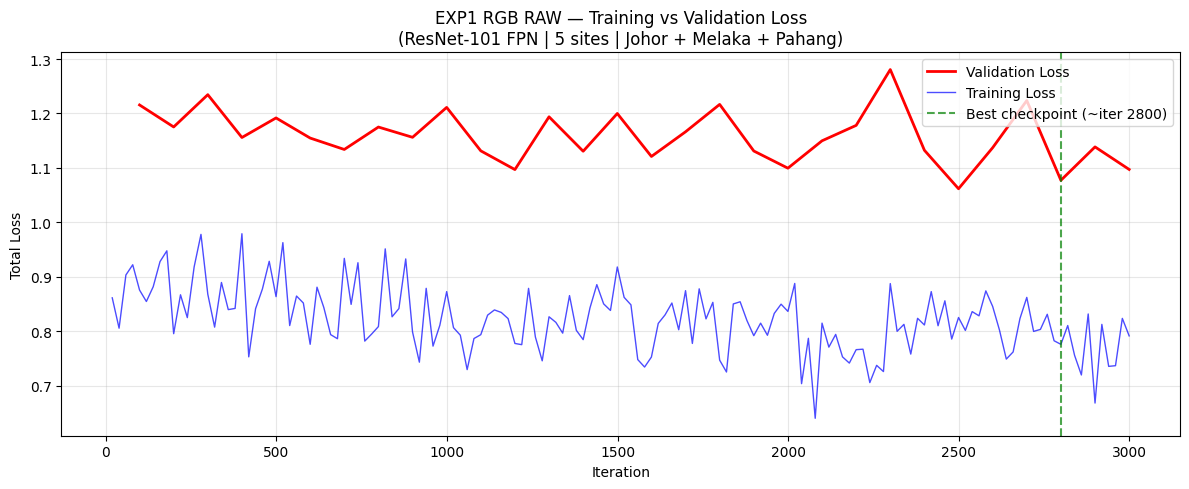

Loss curve saved to Drive


In [ ]:
import json
import matplotlib.pyplot as plt
from detectree2.models.train import load_json_arr

# ── Your experiment folder ─────────────────────────────────────────────
base              = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
experiment_folder = f'{base}/train_outputs'

experiment_metrics = load_json_arr(experiment_folder + '/metrics.json')

# ── Plot Training vs Validation Loss ──────────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(
    [x['iteration'] for x in experiment_metrics if 'validation_loss' in x],
    [x['validation_loss'] for x in experiment_metrics if 'validation_loss' in x],
    label='Validation Loss', color='red', linewidth=2)

plt.plot(
    [x['iteration'] for x in experiment_metrics if 'total_loss' in x],
    [x['total_loss'] for x in experiment_metrics if 'total_loss' in x],
    label='Training Loss', color='blue', linewidth=1, alpha=0.7)

# Mark the best point we found (iter ~2800)
plt.axvline(x=2800, color='green', linestyle='--', alpha=0.7, label='Best checkpoint (~iter 2800)')

plt.legend(loc='upper right')
plt.title('EXP1 RGB RAW — Training vs Validation Loss\n(ResNet-101 FPN | 5 sites | Johor + Melaka + Pahang)')
plt.ylabel('Total Loss')
plt.xlabel('Iteration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{experiment_folder}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved to Drive")

AP50 Curve Plot

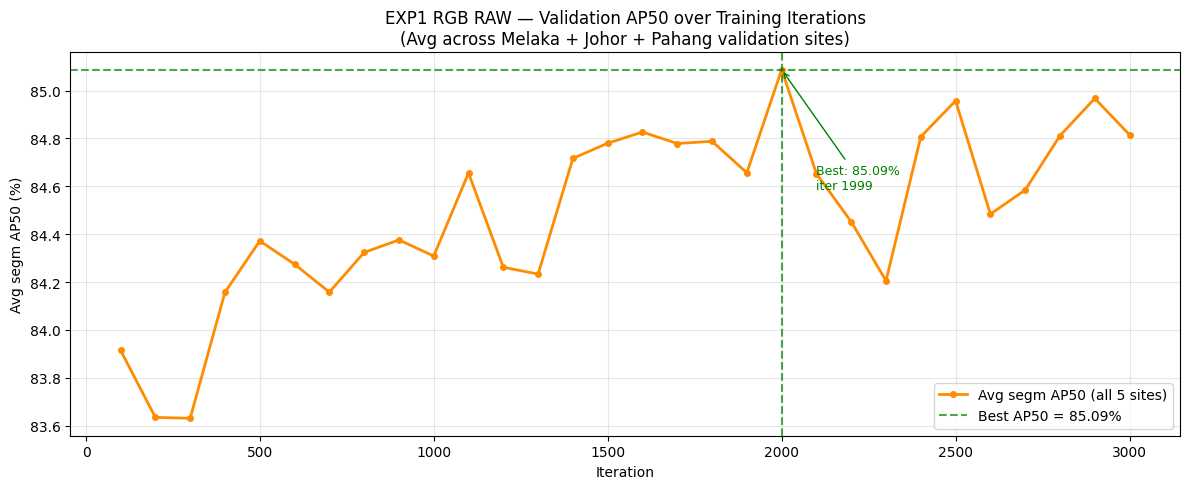

AP50 curve saved to Drive
Best AP50: 85.0877% at iter 1999


In [ ]:
# ── Plot Validation AP50 over iterations ──────────────────────────────
plt.figure(figsize=(12, 5))

plt.plot(
    [x['iteration'] for x in experiment_metrics if 'validation_ap' in x],
    [x['validation_ap'] for x in experiment_metrics if 'validation_ap' in x],
    label='Avg segm AP50 (all 5 sites)', color='darkorange', linewidth=2, marker='o', markersize=4)

# Mark best AP50
best_ap   = max(x['validation_ap'] for x in experiment_metrics if 'validation_ap' in x)
best_iter = next(x['iteration'] for x in experiment_metrics if 'validation_ap' in x and x['validation_ap'] == best_ap)

plt.axhline(y=best_ap, color='green', linestyle='--', alpha=0.7, label=f'Best AP50 = {best_ap:.2f}%')
plt.axvline(x=best_iter, color='green', linestyle='--', alpha=0.7)
plt.annotate(f'Best: {best_ap:.2f}%\niter {best_iter}',
             xy=(best_iter, best_ap),
             xytext=(best_iter + 100, best_ap - 0.5),
             fontsize=9, color='green',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.legend(loc='lower right')
plt.title('EXP1 RGB RAW — Validation AP50 over Training Iterations\n(Avg across Melaka + Johor + Pahang validation sites)')
plt.ylabel('Avg segm AP50 (%)')
plt.xlabel('Iteration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{experiment_folder}/ap50_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AP50 curve saved to Drive")
print(f"Best AP50: {best_ap:.4f}% at iter {best_iter}")

# Evaluating Model Performance and Prediction

Load model, build predictor

In [ ]:
# CELL 1 — LOAD THE TRAINED MODEL INTO GPU MEMORY
#
# PURPOSE:
#   The trained model (model_final.pth) is a file sitting on Google Drive.
#   It cannot do anything until it is loaded into the GPU.
#   This cell loads the model and creates a "predictor" — a ready tool
#   that Cells 2, 3, 4 will use to detect trees in tiles.

#   Run this cell ONCE. Then run Cells 2, 3, 4 without rerunning Cell 1.
# ══════════════════════════════════════════════════════════════════════════

import os
from detectree2.models.train import setup_cfg
from detectron2.engine import DefaultPredictor

# ── Paths ──────────────────────────────────────────────────────────────────
base    = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
out_dir = f'{base}/train_outputs'   # folder where checkpoints were saved

# ── Find best model checkpoint ─────────────────────────────────────────────
# model_final.pth = the last checkpoint saved during
# detectree2 saves this automatically when training finishes or early stops
best_model = f'{out_dir}/model_final.pth'

if not os.path.exists(best_model):
    # Fallback: use the highest numbered checkpoint if model_final not found
    checkpoints = sorted([
        f for f in os.listdir(out_dir)
        if f.startswith('model_') and f.endswith('.pth')
    ])
    best_model = os.path.join(out_dir, checkpoints[-1])
    print(f"model_final.pth not found — using: {os.path.basename(best_model)}")
else:
    print(f"Using: model_final.pth")

# ── Build prediction config ────────────────────────────────────────────────
# setup_cfg needs train/test dataset names as arguments — these are dummy
# placeholders only. They do NOT affect prediction results. setup_cfg just
# needs valid names to build the config object.
base_model = "COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"

cfg_pred = setup_cfg(
    base_model,
    ("Melaka_01_a_train",),   # dummy — ignored during prediction
    ("Melaka_01_a_val",),     # dummy — ignored during prediction
    best_model,               # the actual weights that matter
    workers     = 2,          # data loading workers
    eval_period = 100,
    max_iter    = 1,          # set to 1 because we are not training, just loading
    out_dir     = out_dir,
)

# ── Device: use A100 GPU ───────────────────────────────────────────────────
cfg_pred.MODEL.DEVICE = "cuda"

# ── Confidence threshold = 0.3 ────────────────────────────────────────────
# The model scores every detected crown from 0.0 to 1.0
# Only crowns scoring ABOVE this threshold are kept
#
# WHY 0.3 for this project:
#   - Dense grass in Johor lowers model confidence even on real trees
#   - Small crowns (< 1m²) naturally score lower than large crowns
#   - Coarser GSD in Pahang (4.3cm) makes boundaries less certain
#   - 0.3 keeps more real trees at the cost of some false positives
#
# EFFECT ON YOUR PAPER:
#   - AP50 from training is NOT affected (calculated across all thresholds)
#   - F1, Precision, Recall on test sites ARE affected
#   - You MUST report this value in your paper:
#     "Predictions were generated at confidence threshold 0.3"
cfg_pred.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

# ── Max detections per tile ────────────────────────────────────────────────
# Default is 100. Pahang has dense tiles with 15-20 trees per tile.
# 300 ensures no crowns are cut off in dense areas.
cfg_pred.TEST.DETECTIONS_PER_IMAGE = 300

# ── Create the predictor ───────────────────────────────────────────────────
# This is the object that Cells 2, 3, 4 call to detect trees.
# It loads model_final.pth into GPU memory — takes ~30 seconds.
predictor = DefaultPredictor(cfg_pred)

print("✅ Predictor ready — model loaded into GPU")
print(f"   Model      : {os.path.basename(best_model)}")
print(f"   Device     : {cfg_pred.MODEL.DEVICE}")
print(f"   Threshold  : {cfg_pred.MODEL.ROI_HEADS.SCORE_THRESH_TEST}  (30% confidence)")
print(f"   Max detect : {cfg_pred.TEST.DETECTIONS_PER_IMAGE} per tile")

Using: model_final.pth
[04/12 00:26:34 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/train_outputs/model_final.pth ...


proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}


✅ Predictor ready — model loaded into GPU
   Model      : model_final.pth
   Device     : cuda
   Threshold  : 0.5  (30% confidence)
   Max detect : 300 per tile


PREDICT: 02_MELAKA (TEST SITE)

In [3]:

# Threshold = 0.3 (better recall, fewer missed trees)
# TH_mean, TH_min, TH_max from CHM zonal statistics
# ══════════════════════════════════════════════════════════════════════════
from detectree2.models.outputs import project_to_geojson, stitch_crowns, clean_crowns
from detectree2.models.predict import predict_on_data
from detectree2.models.train import setup_cfg
from detectron2.engine import DefaultPredictor
import geopandas as gpd
import numpy as np
import os

# Install rasterstats if not already installed
try:
    from rasterstats import zonal_stats
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'rasterstats', '-q'])
    from rasterstats import zonal_stats

base          = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
trained_model = f'{base}/train_outputs/250312_flexi.pth'

# CHM path — from EXP_4Ms which has all CHM files already in UTM
chm_base  = '/content/drive/MyDrive/data_ITCD/EXP_4Ms(rawGSD)'
chm_path  = f'{chm_base}/Melaka/02_Melaka/Rastered_Data/CHM_MKF1_UTM.tif'

site_path     = f'{base}/Melaka/02_Melaka'
tiles_path    = site_path + '/tiles/'
pred_path     = site_path + '/tiles/predictions/'
pred_geo_path = site_path + '/tiles/predictions_geo/'
gt_path       = site_path + '/Attributes/02_Melaka_crowns_UTM.gpkg'
output_path   = site_path + '/02_Melaka_predicted_crowns.gpkg'

os.makedirs(pred_path,     exist_ok=True)
os.makedirs(pred_geo_path, exist_ok=True)

# ── Predict ────────────────────────────────────────────────────────────────
cfg = setup_cfg(update_model=trained_model)
cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # 0.3 = better recall

predict_on_data(tiles_path, out_folder=pred_path, predictor=DefaultPredictor(cfg))
print("✅ Predictions done —", len([f for f in os.listdir(pred_path) if f.endswith('.json')]), "JSON files")

project_to_geojson(tiles_path, pred_path, pred_geo_path)
print("✅ Projected to GeoJSON")

crowns = stitch_crowns(pred_geo_path, 1)
clean  = clean_crowns(crowns, 0.6, confidence=0.3)
clean  = clean.set_geometry(clean.simplify(0.3))
print(f"✅ Crowns after cleaning: {len(clean)}")

# ── Compute attributes ─────────────────────────────────────────────────────
clean_geo  = clean.to_crs(epsg=4326)
centroids  = clean_geo.geometry.centroid

clean['id']        = range(0, len(clean))
clean['arae']      = clean.geometry.area.round(4)
clean['latitude']  = centroids.y.round(8)
clean['longitude'] = centroids.x.round(8)
clean['tree_code'] = ['MY0000PRED_' + str(i).zfill(4) for i in range(len(clean))]
clean['crown_area_m2'] = clean['arae']
clean['crown_diam_m']  = (2 * (clean['arae'] / 3.14159) ** 0.5).round(4)

# ── Zonal statistics from CHM ──────────────────────────────────────────────
# Extracts mean, min, max height value from CHM raster
# for each predicted crown polygon
print("\nExtracting tree heights from CHM...")
if os.path.exists(chm_path):
    stats = zonal_stats(
        clean.geometry,        # predicted crown polygons
        chm_path,              # CHM raster
        stats=['mean', 'min', 'max'],
        affine=None,
        nodata=-9999
    )
    clean['TH_mean'] = [round(s['mean'], 6) if s['mean'] is not None else np.nan for s in stats]
    clean['TH_min']  = [round(s['min'],  6) if s['min']  is not None else np.nan for s in stats]
    clean['TH_max']  = [round(s['max'],  6) if s['max']  is not None else np.nan for s in stats]
    print(f"✅ Heights extracted — TH_mean range: {clean['TH_mean'].min():.2f} – {clean['TH_mean'].max():.2f} m")
else:
    print(f"⚠️  CHM not found at: {chm_path}")
    print(f"   TH columns set to null — check path")
    clean['TH_mean'] = np.nan
    clean['TH_min']  = np.nan
    clean['TH_max']  = np.nan

# ── Match any remaining columns from ground truth ─────────────────────────
gt = gpd.read_file(gt_path)
for col in [c for c in gt.columns if c != 'geometry']:
    if col not in clean.columns:
        clean[col] = np.nan

# ── Save ──────────────────────────────────────────────────────────────────
clean.to_file(output_path, driver='GPKG')
print(f"\n✅ SAVED: {output_path}")
print(f"   Predicted crowns : {len(clean)}")
print(f"   Ground truth     : {len(gt)}")
print(f"   Columns          : {[c for c in clean.columns if c != 'geometry']}")



AttributeError: module 'sympy' has no attribute 'printing'

PREDICT 02_JOHOR

In [ ]:
# CELL 3 — PREDICT 02_JOHOR
# Threshold = 0.3 | TH from CHM zonal statistics
# ══════════════════════════════════════════════════════════════════════════
from detectree2.models.outputs import project_to_geojson, stitch_crowns, clean_crowns
from detectree2.models.predict import predict_on_data
from detectree2.models.train import setup_cfg
from detectron2.engine import DefaultPredictor
from rasterstats import zonal_stats
import geopandas as gpd
import numpy as np
import os

base          = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
trained_model = f'{base}/train_outputs/model_final.pth'

chm_base  = '/content/drive/MyDrive/data_ITCD/EXP_4Ms(rawGSD)'
chm_path  = f'{chm_base}/Johor/02_Johor/Rastered_Data/CHM_MATANG_02_UTM.tif'

site_path     = f'{base}/Johor/02_Johor'
tiles_path    = site_path + '/tiles/'
pred_path     = site_path + '/tiles/predictions/'
pred_geo_path = site_path + '/tiles/predictions_geo/'
gt_path       = site_path + '/Atrributes/02_Johor_crowns_UTM.gpkg'
output_path   = site_path + '/02_Johor_predicted_crowns.gpkg'

os.makedirs(pred_path,     exist_ok=True)
os.makedirs(pred_geo_path, exist_ok=True)

cfg = setup_cfg(update_model=trained_model)
cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3

predict_on_data(tiles_path, out_folder=pred_path, predictor=DefaultPredictor(cfg))
print("✅ Predictions done —", len([f for f in os.listdir(pred_path) if f.endswith('.json')]), "JSON files")

project_to_geojson(tiles_path, pred_path, pred_geo_path)
print("✅ Projected to GeoJSON")

crowns = stitch_crowns(pred_geo_path, 1)
clean  = clean_crowns(crowns, 0.6, confidence=0.3)
clean  = clean.set_geometry(clean.simplify(0.3))
print(f"✅ Crowns after cleaning: {len(clean)}")

clean_geo  = clean.to_crs(epsg=4326)
centroids  = clean_geo.geometry.centroid

clean['id']        = range(0, len(clean))
clean['arae']      = clean.geometry.area.round(4)
clean['latitude']  = centroids.y.round(8)
clean['longitude'] = centroids.x.round(8)
clean['tree_code'] = ['MY0000PRED_' + str(i).zfill(4) for i in range(len(clean))]
clean['crown_area_m2'] = clean['arae']
clean['crown_diam_m']  = (2 * (clean['arae'] / 3.14159) ** 0.5).round(4)

print("\nExtracting tree heights from CHM...")
if os.path.exists(chm_path):
    stats = zonal_stats(clean.geometry, chm_path,
                        stats=['mean', 'min', 'max'], nodata=-9999)
    clean['TH_mean'] = [round(s['mean'], 6) if s['mean'] is not None else np.nan for s in stats]
    clean['TH_min']  = [round(s['min'],  6) if s['min']  is not None else np.nan for s in stats]
    clean['TH_max']  = [round(s['max'],  6) if s['max']  is not None else np.nan for s in stats]
    print(f"✅ Heights extracted — TH_mean range: {clean['TH_mean'].min():.2f} – {clean['TH_mean'].max():.2f} m")
else:
    print(f"⚠️  CHM not found: {chm_path}")
    clean['TH_mean'] = np.nan
    clean['TH_min']  = np.nan
    clean['TH_max']  = np.nan

gt = gpd.read_file(gt_path)
for col in [c for c in gt.columns if c != 'geometry']:
    if col not in clean.columns:
        clean[col] = np.nan

clean.to_file(output_path, driver='GPKG')
print(f"\n✅ SAVED: {output_path}")
print(f"   Predicted crowns : {len(clean)}")
print(f"   Ground truth     : {len(gt)}")


[04/12 00:56:31 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/train_outputs/model_final.pth ...


proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}
Predicting files in mode rgb: 100%|██████████| 293/293 [01:32<00:00,  3.18it/s]


✅ Predictions done — 293 JSON files


Projecting files: 100%|██████████| 293/293 [00:12<00:00, 24.28it/s]


✅ Projected to GeoJSON


Stitching crowns: 100%|██████████| 293/293 [00:03<00:00, 80.37file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 1420/1420 [00:00<00:00, 4057.69it/s]
/tmp/ipykernel_76044/3953525323.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids  = clean_geo.geometry.centroid


✅ Crowns after cleaning: 156

Extracting tree heights from CHM...
⚠️  CHM not found: /content/drive/MyDrive/data_ITCD/EXP_4Ms(rawGSD)/Johor/02_Johor/Rastered_Data/CHM_MATANG_02_UTM.tif

✅ SAVED: /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Johor/02_Johor/02_Johor_predicted_crowns.gpkg
   Predicted crowns : 156
   Ground truth     : 333


PREDICT 02_PAHANG

In [ ]:
from detectree2.models.outputs import project_to_geojson, stitch_crowns, clean_crowns
from detectree2.models.predict import predict_on_data
from detectree2.models.train import setup_cfg
from detectron2.engine import DefaultPredictor
from rasterstats import zonal_stats
import geopandas as gpd
import numpy as np
import os

base          = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'
trained_model = f'{base}/train_outputs/model_final.pth'

chm_base  = '/content/drive/MyDrive/data_ITCD/EXP_4Ms(rawGSD)'
chm_path  = f'{chm_base}/Pahang/02_Pahang/Rastered_Data/CHM_Pahang_02_UTM.tif'

site_path     = f'{base}/Pahang/02_Pahang'
tiles_path    = site_path + '/tiles/'
pred_path     = site_path + '/tiles/predictions/'
pred_geo_path = site_path + '/tiles/predictions_geo/'
gt_path       = site_path + '/Attributes/02_Pahang_crowns_UTM.gpkg'
output_path   = site_path + '/02_Pahang_predicted_crowns.gpkg'

os.makedirs(pred_path,     exist_ok=True)
os.makedirs(pred_geo_path, exist_ok=True)

cfg = setup_cfg(update_model=trained_model)
cfg.MODEL.DEVICE = "cuda"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3

predict_on_data(tiles_path, out_folder=pred_path, predictor=DefaultPredictor(cfg))
print("✅ Predictions done —", len([f for f in os.listdir(pred_path) if f.endswith('.json')]), "JSON files")

project_to_geojson(tiles_path, pred_path, pred_geo_path)
print("✅ Projected to GeoJSON")

crowns = stitch_crowns(pred_geo_path, 1)
clean  = clean_crowns(crowns, 0.6, confidence=0.3)
clean  = clean.set_geometry(clean.simplify(0.3))
print(f"✅ Crowns after cleaning: {len(clean)}")

clean_geo  = clean.to_crs(epsg=4326)
centroids  = clean_geo.geometry.centroid

clean['id']        = range(0, len(clean))
clean['arae']      = clean.geometry.area.round(4)
clean['latitude']  = centroids.y.round(8)
clean['longitude'] = centroids.x.round(8)
clean['tree_code'] = ['MY0000PRED_' + str(i).zfill(4) for i in range(len(clean))]
clean['crown_area_m2'] = clean['arae']
clean['crown_diam_m']  = (2 * (clean['arae'] / 3.14159) ** 0.5).round(4)

print("\nExtracting tree heights from CHM...")
if os.path.exists(chm_path):
    stats = zonal_stats(clean.geometry, chm_path,
                        stats=['mean', 'min', 'max'], nodata=-9999)
    clean['TH_mean'] = [round(s['mean'], 6) if s['mean'] is not None else np.nan for s in stats]
    clean['TH_min']  = [round(s['min'],  6) if s['min']  is not None else np.nan for s in stats]
    clean['TH_max']  = [round(s['max'],  6) if s['max']  is not None else np.nan for s in stats]
    print(f"✅ Heights extracted — TH_mean range: {clean['TH_mean'].min():.2f} – {clean['TH_mean'].max():.2f} m")
else:
    print(f"⚠️  CHM not found: {chm_path}")
    clean['TH_mean'] = np.nan
    clean['TH_min']  = np.nan
    clean['TH_max']  = np.nan

gt = gpd.read_file(gt_path)
for col in [c for c in gt.columns if c != 'geometry']:
    if col not in clean.columns:
        clean[col] = np.nan

clean.to_file(output_path, driver='GPKG')
print(f"\n✅ SAVED: {output_path}")
print(f"   Predicted crowns : {len(clean)}")
print(f"   Ground truth     : {len(gt)}")

[04/12 01:00:08 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/train_outputs/model_final.pth ...


proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}
Predicting files in mode rgb: 100%|██████████| 98/98 [00:27<00:00,  3.53it/s]


✅ Predictions done — 98 JSON files


Projecting files: 100%|██████████| 98/98 [00:02<00:00, 38.68it/s]


✅ Projected to GeoJSON


Stitching crowns: 100%|██████████| 98/98 [00:00<00:00, 99.00file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 98/98 [00:00<00:00, 2254.35it/s]
/tmp/ipykernel_76044/72930408.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids  = clean_geo.geometry.centroid


✅ Crowns after cleaning: 99

Extracting tree heights from CHM...
⚠️  CHM not found: /content/drive/MyDrive/data_ITCD/EXP_4Ms(rawGSD)/Pahang/02_Pahang/Rastered_Data/CHM_Pahang_02_UTM.tif

✅ SAVED: /content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)/Pahang/02_Pahang/02_Pahang_predicted_crowns.gpkg
   Predicted crowns : 99
   Ground truth     : 307


evaluate metrics

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CELL — FULL METRICS EVALUATION
# Evaluates all 3 test sites against ground truth
#
# METRICS COMPUTED:
#   1. Tree counting accuracy (predicted vs ground truth count)
#   2. Precision  — of all predicted crowns, how many are real trees
#   3. Recall     — of all real trees, how many did we find
#   4. F1 score   — balance between precision and recall
#   5. IoU        — average overlap between matched crowns
#   6. AP50       — average precision at 50% IoU threshold
#   7. Crown area R² — how well predicted area matches ground truth
#   8. Crown diameter R² — how well predicted diameter matches ground truth
#   9. TH_mean comparison — predicted vs ground truth tree height
# ══════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Install sklearn if needed
try:
    from sklearn.metrics import r2_score
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'scikit-learn', '-q'])
    from sklearn.metrics import r2_score

base = '/content/drive/MyDrive/data_ITCD/EXP_1RGB(rawGSD)'

# ── Site configuration ─────────────────────────────────────────────────────
sites = {
    '02_Melaka': {
        'pred': f'{base}/Melaka/02_Melaka/02_Melaka_predicted_crowns.gpkg',
        'gt':   f'{base}/Melaka/02_Melaka/Attributes/02_Melaka_crowns_UTM.gpkg',
    },
    '02_Johor': {
        'pred': f'{base}/Johor/02_Johor/02_Johor_predicted_crowns.gpkg',
        'gt':   f'{base}/Johor/02_Johor/Atrributes/02_Johor_crowns_UTM.gpkg',
    },
    '02_Pahang': {
        'pred': f'{base}/Pahang/02_Pahang/02_Pahang_predicted_crowns.gpkg',
        'gt':   f'{base}/Pahang/02_Pahang/Attributes/02_Pahang_crowns_UTM.gpkg',
    },
}

# ── Core matching function ─────────────────────────────────────────────────
def match_crowns(pred_gdf, gt_gdf, iou_threshold=0.5):
    """
    Match predicted crowns to ground truth crowns using IoU.
    Returns: TP, FP, FN counts and list of IoU values for matched pairs.

    HOW IT WORKS:
    For each predicted crown, find the ground truth crown with the
    highest IoU overlap. If IoU >= threshold → True Positive (correct detection).
    Unmatched predictions → False Positives.
    Unmatched ground truth → False Negatives (missed trees).
    """
    matched_gt  = set()
    matched_pred = set()
    iou_values  = []

    # Build spatial index for speed
    gt_sindex = gt_gdf.sindex

    for pred_idx, pred_row in pred_gdf.iterrows():
        pred_geom = pred_row.geometry
        if pred_geom is None or pred_geom.is_empty:
            continue

        # Find candidate GT crowns that overlap with prediction bounding box
        candidates = list(gt_sindex.intersection(pred_geom.bounds))

        best_iou  = 0
        best_gt   = None

        for gt_idx in candidates:
            if gt_idx in matched_gt:
                continue   # already matched to another prediction
            gt_geom = gt_gdf.iloc[gt_idx].geometry
            if gt_geom is None or gt_geom.is_empty:
                continue
            try:
                intersection = pred_geom.intersection(gt_geom).area
                union        = pred_geom.union(gt_geom).area
                iou = intersection / union if union > 0 else 0
            except Exception:
                iou = 0

            if iou > best_iou:
                best_iou = iou
                best_gt  = gt_idx

        if best_iou >= iou_threshold and best_gt is not None:
            matched_gt.add(best_gt)
            matched_pred.add(pred_idx)
            iou_values.append(best_iou)

    TP = len(matched_pred)
    FP = len(pred_gdf) - TP
    FN = len(gt_gdf)   - TP

    return TP, FP, FN, iou_values


def compute_ap50(pred_gdf, gt_gdf):
    """
    Compute AP50 — Average Precision at IoU threshold 0.5.
    Sorts predictions by confidence score (highest first),
    then builds precision-recall curve.
    """
    if 'Confidence_score' not in pred_gdf.columns:
        # If no confidence scores, use uniform score
        pred_sorted = pred_gdf.copy()
        pred_sorted['Confidence_score'] = 1.0
    else:
        pred_sorted = pred_gdf.sort_values('Confidence_score', ascending=False)

    n_gt = len(gt_gdf)
    matched_gt = set()
    gt_sindex  = gt_gdf.sindex

    precisions = []
    recalls    = []
    tp_count   = 0

    for rank, (pred_idx, pred_row) in enumerate(pred_sorted.iterrows(), 1):
        pred_geom  = pred_row.geometry
        candidates = list(gt_sindex.intersection(pred_geom.bounds))
        best_iou   = 0
        best_gt    = None

        for gt_idx in candidates:
            if gt_idx in matched_gt:
                continue
            gt_geom = gt_gdf.iloc[gt_idx].geometry
            try:
                inter = pred_geom.intersection(gt_geom).area
                union = pred_geom.union(gt_geom).area
                iou   = inter / union if union > 0 else 0
            except Exception:
                iou = 0
            if iou > best_iou:
                best_iou = iou
                best_gt  = gt_idx

        if best_iou >= 0.5 and best_gt is not None:
            matched_gt.add(best_gt)
            tp_count += 1

        precision = tp_count / rank
        recall    = tp_count / n_gt if n_gt > 0 else 0
        precisions.append(precision)
        recalls.append(recall)

    # Compute area under precision-recall curve
    if not precisions:
        return 0.0
    precisions = np.array(precisions)
    recalls    = np.array(recalls)
    ap50 = np.trapz(precisions, recalls) if len(recalls) > 1 else 0.0
    return round(float(ap50) * 100, 2)


# ══════════════════════════════════════════════════════════════════════════
# MAIN EVALUATION LOOP
# ══════════════════════════════════════════════════════════════════════════

all_results = {}
iou_thresholds = [0.5, 0.75]   # evaluate at both IoU 0.5 and 0.75

print("=" * 65)
print("FULL METRICS EVALUATION — EXP1 RGB RAW")
print("Confidence threshold: 0.3")
print("=" * 65)

for site_name, paths in sites.items():

    if not os.path.exists(paths['pred']):
        print(f"\n❌ {site_name} — predicted gpkg not found")
        continue
    if not os.path.exists(paths['gt']):
        print(f"\n❌ {site_name} — ground truth gpkg not found")
        continue

    pred_gdf = gpd.read_file(paths['pred'])
    gt_gdf   = gpd.read_file(paths['gt'])

    # Make sure both are in same CRS
    if pred_gdf.crs != gt_gdf.crs:
        pred_gdf = pred_gdf.to_crs(gt_gdf.crs)

    # Remove invalid geometries
    pred_gdf = pred_gdf[pred_gdf.is_valid & ~pred_gdf.geometry.is_empty].reset_index(drop=True)
    gt_gdf   = gt_gdf[gt_gdf.is_valid   & ~gt_gdf.geometry.is_empty].reset_index(drop=True)

    print(f"\n{'━'*65}")
    print(f"SITE: {site_name}")
    print(f"{'━'*65}")

    # ── 1. Tree counting ────────────────────────────────────────────────
    n_pred   = len(pred_gdf)
    n_gt     = len(gt_gdf)
    count_diff = n_pred - n_gt
    count_acc  = round(min(n_pred, n_gt) / n_gt * 100, 1)

    print(f"\n  TREE COUNTING:")
    print(f"    Ground truth  : {n_gt}")
    print(f"    Predicted     : {n_pred}")
    print(f"    Difference    : {count_diff:+d}")
    print(f"    Count accuracy: {count_acc}%")

    # ── 2. Precision, Recall, F1 at IoU 0.5 ────────────────────────────
    TP50, FP50, FN50, iou_vals50 = match_crowns(pred_gdf, gt_gdf, iou_threshold=0.5)

    precision50 = round(TP50 / (TP50 + FP50) * 100, 2) if (TP50 + FP50) > 0 else 0
    recall50    = round(TP50 / (TP50 + FN50) * 100, 2) if (TP50 + FN50) > 0 else 0
    f1_50       = round(2 * precision50 * recall50 / (precision50 + recall50), 2) if (precision50 + recall50) > 0 else 0
    mean_iou50  = round(np.mean(iou_vals50) * 100, 2) if iou_vals50 else 0

    print(f"\n  AT IoU 0.50:")
    print(f"    TP={TP50}  FP={FP50}  FN={FN50}")
    print(f"    Precision : {precision50}%")
    print(f"    Recall    : {recall50}%")
    print(f"    F1        : {f1_50}%")
    print(f"    Mean IoU  : {mean_iou50}%")

    # ── 3. Precision, Recall, F1 at IoU 0.75 ────────────────────────────
    TP75, FP75, FN75, iou_vals75 = match_crowns(pred_gdf, gt_gdf, iou_threshold=0.75)

    precision75 = round(TP75 / (TP75 + FP75) * 100, 2) if (TP75 + FP75) > 0 else 0
    recall75    = round(TP75 / (TP75 + FN75) * 100, 2) if (TP75 + FN75) > 0 else 0
    f1_75       = round(2 * precision75 * recall75 / (precision75 + recall75), 2) if (precision75 + recall75) > 0 else 0

    print(f"\n  AT IoU 0.75:")
    print(f"    TP={TP75}  FP={FP75}  FN={FN75}")
    print(f"    Precision : {precision75}%")
    print(f"    Recall    : {recall75}%")
    print(f"    F1        : {f1_75}%")

    # ── 4. AP50 ─────────────────────────────────────────────────────────
    ap50 = compute_ap50(pred_gdf, gt_gdf)
    print(f"\n  AP50      : {ap50}%")

    # ── 5. Crown area R² ────────────────────────────────────────────────
    # Match predicted to GT crowns then compare their areas
    pred_areas = []
    gt_areas   = []
    gt_sindex  = gt_gdf.sindex

    matched_gt_set = set()
    for _, pred_row in pred_gdf.iterrows():
        pred_geom  = pred_row.geometry
        candidates = list(gt_sindex.intersection(pred_geom.bounds))
        best_iou, best_gt = 0, None
        for gt_idx in candidates:
            if gt_idx in matched_gt_set:
                continue
            gt_geom = gt_gdf.iloc[gt_idx].geometry
            try:
                iou = pred_geom.intersection(gt_geom).area / pred_geom.union(gt_geom).area
            except Exception:
                iou = 0
            if iou > best_iou:
                best_iou, best_gt = iou, gt_idx
        if best_iou >= 0.5 and best_gt is not None:
            matched_gt_set.add(best_gt)
            pred_areas.append(pred_geom.area)
            if 'arae' in gt_gdf.columns:
                gt_areas.append(gt_gdf.iloc[best_gt]['arae'])
            else:
                gt_areas.append(gt_gdf.iloc[best_gt].geometry.area)

    if len(pred_areas) > 1:
        r2_area = round(r2_score(gt_areas, pred_areas), 4)
        rmse_area = round(np.sqrt(np.mean((np.array(pred_areas) - np.array(gt_areas))**2)), 4)
        print(f"\n  CROWN AREA (matched pairs n={len(pred_areas)}):")
        print(f"    R²   : {r2_area}")
        print(f"    RMSE : {rmse_area} m²")
        print(f"    GT mean  : {round(np.mean(gt_areas), 2)} m²")
        print(f"    Pred mean: {round(np.mean(pred_areas), 2)} m²")
    else:
        r2_area = None
        print(f"\n  CROWN AREA: not enough matched pairs")

    # ── 6. Height comparison (if TH_mean available) ─────────────────────
    if 'TH_mean' in pred_gdf.columns and pred_gdf['TH_mean'].notna().sum() > 10:
        th_pred = pred_gdf['TH_mean'].dropna()
        print(f"\n  TREE HEIGHT (from CHM):")
        print(f"    TH_mean mean : {th_pred.mean():.2f} m")
        print(f"    TH_mean range: {th_pred.min():.2f} – {th_pred.max():.2f} m")
        if 'TH_mean' in gt_gdf.columns and gt_gdf['TH_mean'].notna().sum() > 10:
            th_gt = gt_gdf['TH_mean'].dropna()
            print(f"    GT TH_mean   : {th_gt.mean():.2f} m (ground truth)")

    # Store results
    all_results[site_name] = {
        'n_gt': n_gt, 'n_pred': n_pred, 'count_acc': count_acc,
        'precision50': precision50, 'recall50': recall50, 'f1_50': f1_50,
        'precision75': precision75, 'recall75': recall75, 'f1_75': f1_75,
        'mean_iou50': mean_iou50, 'ap50': ap50, 'r2_area': r2_area,
    }

# ══════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE — ready to copy into paper
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print("SUMMARY TABLE — EXP1 RGB RAW")
print(f"{'='*65}")
print(f"{'Site':<14} {'GT':>5} {'Pred':>5} {'Acc%':>6} {'Prec%':>7} {'Rec%':>6} {'F1%':>6} {'AP50%':>7}")
print("-" * 65)

for site, r in all_results.items():
    short = site.replace('0', '').replace('_', '')
    print(f"{site:<14} {r['n_gt']:>5} {r['n_pred']:>5} {r['count_acc']:>6} "
          f"{r['precision50']:>7} {r['recall50']:>6} {r['f1_50']:>6} {r['ap50']:>7}")

print(f"{'='*65}")

# ── Save results to CSV ────────────────────────────────────────────────────
results_df  = pd.DataFrame(all_results).T
csv_path    = f'{base}/predictions/EXP1_metrics.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
results_df.to_csv(csv_path)
print(f"\nResults saved to: {csv_path}")

# ── Plot precision-recall bar chart ───────────────────────────────────────
if all_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sites_list = list(all_results.keys())
    colors = ['#2196F3', '#4CAF50', '#FF9800']

    # F1 scores
    ax = axes[0]
    vals = [all_results[s]['f1_50'] for s in sites_list]
    bars = ax.bar(sites_list, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('F1 Score @ IoU 0.5', fontweight='bold')
    ax.set_ylabel('F1 Score (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    # Precision vs Recall
    ax = axes[1]
    x = np.arange(len(sites_list))
    w = 0.35
    b1 = ax.bar(x - w/2, [all_results[s]['precision50'] for s in sites_list],
                w, label='Precision', color='#2196F3', edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + w/2, [all_results[s]['recall50'] for s in sites_list],
                w, label='Recall',    color='#4CAF50', edgecolor='black', linewidth=0.5)
    ax.set_title('Precision vs Recall @ IoU 0.5', fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(sites_list, rotation=15)
    ax.legend()

    # AP50
    ax = axes[2]
    vals = [all_results[s]['ap50'] for s in sites_list]
    bars = ax.bar(sites_list, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('AP50', fontweight='bold')
    ax.set_ylabel('AP50 (%)')
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

    plt.suptitle('EXP1 RGB RAW — Test Site Evaluation Metrics',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    fig_path = f'{base}/predictions/EXP1_metrics_chart.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Chart saved to: {fig_path}")

print("\nDone.")

FULL METRICS EVALUATION — EXP1 RGB RAW
Confidence threshold: 0.3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SITE: 02_Melaka
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  TREE COUNTING:
    Ground truth  : 370
    Predicted     : 294
    Difference    : -76
    Count accuracy: 79.5%

  AT IoU 0.50:
    TP=251  FP=43  FN=119
    Precision : 85.37%
    Recall    : 67.84%
    F1        : 75.6%
    Mean IoU  : 74.42%

  AT IoU 0.75:
    TP=131  FP=163  FN=239
    Precision : 44.56%
    Recall    : 35.41%
    F1        : 39.46%

  AP50      : 64.79%

  CROWN AREA (matched pairs n=251):
    R²   : 0.8943
    RMSE : 1.5538 m²
    GT mean  : 8.45 m²
    Pred mean: 8.18 m²

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SITE: 02_Johor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  TREE COUNTING:
    Ground truth  : 324
    Predicted     : 156
    Difference    : -168
    Count accuracy: 48.1%

  AT IoU 0.50:


# Exp_2

INSPECT EXP_2RGB(5cmGSD) DATA

In [ ]:
import os
import rasterio
import geopandas as gpd
from pathlib import Path

base2 = '/content/drive/MyDrive/data_ITCD/EXP_2RGB(5cmGSD)'

RASTER_EXT = ['.tif', '.tiff']
VECTOR_EXT = ['.gpkg', '.shp', '.geojson']

print("=" * 65)
print("DATA INSPECTION — EXP_2RGB(5cmGSD)")
print("=" * 65)

for state in ['Johor', 'Melaka', 'Pahang']:
    state_path = os.path.join(base2, state)
    if not os.path.isdir(state_path):
        print(f"\n❌ {state} not found")
        continue

    print(f"\n{'━'*65}")
    print(f"STATE: {state.upper()}")
    print(f"{'━'*65}")

    for site in sorted(os.listdir(state_path)):
        site_path = os.path.join(state_path, site)
        if not os.path.isdir(site_path):
            continue

        print(f"\n  SITE: {site.strip()}")

        for root, dirs, files in os.walk(site_path):
            if 'tile' in root.lower():
                continue

            rasters = [f for f in files if Path(f).suffix.lower() in RASTER_EXT]
            vectors = [f for f in files if Path(f).suffix.lower() in VECTOR_EXT]

            if not rasters and not vectors:
                continue

            rel = os.path.relpath(root, base2)
            print(f"\n    📁 {rel}")

            for fname in sorted(rasters):
                fpath = os.path.join(root, fname)
                try:
                    with rasterio.open(fpath) as src:
                        epsg   = src.crs.to_epsg() if src.crs else None
                        gsd_cm = round(src.res[0] * 100, 2)
                        bands  = src.count
                        w, h   = src.width, src.height
                        mb     = round(os.path.getsize(fpath)/1024/1024, 1)
                        ok     = "✅ UTM" if epsg and 32600<=epsg<=32800 else f"❌ EPSG:{epsg}"
                    print(f"    [RASTER] {fname}")
                    print(f"             {ok} | GSD:{gsd_cm}cm | {bands}band | {w}x{h}px | {mb}MB")
                except Exception as e:
                    print(f"    [RASTER] {fname} — ❌ ERROR: {e}")

            for fname in sorted(vectors):
                fpath = os.path.join(root, fname)
                try:
                    gdf  = gpd.read_file(fpath)
                    epsg = gdf.crs.to_epsg() if gdf.crs else None
                    ok   = "✅ UTM" if epsg and 32600<=epsg<=32800 else f"❌ EPSG:{epsg}"
                    mb   = round(os.path.getsize(fpath)/1024/1024, 1)
                    print(f"    [VECTOR] {fname}")
                    print(f"             {ok} | {len(gdf)} features | {mb}MB")
                except Exception as e:
                    print(f"    [VECTOR] {fname} — ❌ ERROR: {e}")

print(f"\n{'='*65}")
print("Inspection complete — check paths above before tiling")
print("=" * 65)

tiling of Second Exper(Johor)

In [ ]:
from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

base2       = '/content/drive/MyDrive/data_ITCD/EXP_2RGB(5cmGSD)'
johor_base  = f'{base2}/Johor'

sites_johor = {
    '01_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_0_UTM.tif',
        'crown': 'Atrributes/01_Johor_crowns_UTM.gpkg',   # typo preserved
        'role':  'train'
    },
    '02_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_02_UTM.tif',
        'crown': 'Atrributes/02_Johor_crowns_UTM.gpkg',
        'role':  'test'
    },
    '03_Johor': {
        'img':   'Rastered_Data/ORTHORGB_MATANG_03_UTM.tif',
        'crown': 'Atrributes/03_Johor_crowns_UTM.gpkg',
        'role':  'train'
    },
}

for site_name, info in sites_johor.items():
    print(f"\n{'='*55}")
    print(f"JOHOR EXP2 — {site_name} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{johor_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown not found: {crown_path}")
        continue

    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns: {len(crowns)} valid polygons")

    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 5,
        tile_width           = 15,
        tile_height          = 15,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ PNG: {n_png} | GeoJSON: {n_json}")

    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)
    role_msg = "TRAIN" if info['role']=='train' else "TEST (excluded from training)"
    print(f"✅ Split done — {role_msg}")

print(f"\n{'='*55}")
print("JOHOR EXP2 TILING COMPLETE")
print("=" * 55)


In [ ]:
tiling of Second Exper(Melaka)

In [ ]:
from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

base2        = '/content/drive/MyDrive/data_ITCD/EXP_2RGB(5cmGSD)'
melaka_base  = f'{base2}/Melaka'

sites_melaka = {
    '01_Melaka': {
        'img':   'Rastered_Data/MKF2_RGB_UTM.tif',
        'crown': 'Attributes/01_Melaka_crowns_UTM.gpkg',
        'role':  'train'
    },
    '02_Melaka': {
        'img':   'Rastered_Data/ORTHO_MKF1_RGB_UTM.tif',   # underscore version (resampled)
        'crown': 'Attributes/02_Melaka_crowns_UTM.gpkg',
        'role':  'test'
    },
}

for site_name, info in sites_melaka.items():
    print(f"\n{'='*55}")
    print(f"MELAKA EXP2 — {site_name} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{melaka_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        print(f"   Check inspection output above for correct filename")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown not found: {crown_path}")
        continue

    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns: {len(crowns)} valid polygons")

    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 5,
        tile_width           = 15,
        tile_height          = 15,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ PNG: {n_png} | GeoJSON: {n_json}")

    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)
    role_msg = "TRAIN" if info['role']=='train' else "TEST (excluded from training)"
    print(f"✅ Split done — {role_msg}")

print(f"\n{'='*55}")
print("MELAKA EXP2 TILING COMPLETE")
print("=" * 55)



tiling of Second Exper(Pahang)

In [ ]:
from detectree2.preprocessing.tiling import tile_data, to_traintest_folders
import geopandas as gpd
import os, shutil

base2       = '/content/drive/MyDrive/data_ITCD/EXP_2RGB(5cmGSD)'
pahang_base = f'{base2}/Pahang'

sites_pahang = {
    '01_Pahang ': {            # trailing space — DO NOT REMOVE
        'img':   'Rastered_Data/Ortho_Pahang_01_UTM.tif',
        'crown': 'Attributes/01_Pahang_crowns_UTM.gpkg',
        'role':  'train'
    },
    '02_Pahang': {
        'img':   'Rastered_Data/ORTHORGB_Pahang_02_UTM.tif',
        'crown': 'Attributes/02_Pahang_crowns_UTM.gpkg',
        'role':  'test'
    },
    '03_Pahang': {
        'img':   'Rastered_Data/ORTHORGB_Pahang_03_UTM.tif',
        'crown': 'Attributes/03_Pahang_crowns_UTM.gpkg',
        'role':  'train'
    },
}

for site_name, info in sites_pahang.items():
    print(f"\n{'='*55}")
    print(f"PAHANG EXP2 — {site_name.strip()} ({info['role'].upper()})")
    print(f"{'='*55}")

    site_path  = f'{pahang_base}/{site_name}'
    img_path   = f'{site_path}/{info["img"]}'
    crown_path = f'{site_path}/{info["crown"]}'
    out_dir    = f'{site_path}/tiles/'

    if not os.path.exists(img_path):
        print(f"❌ Image not found: {img_path}")
        continue
    if not os.path.exists(crown_path):
        print(f"❌ Crown not found: {crown_path}")
        continue

    crowns = gpd.read_file(crown_path)
    crowns['geometry'] = crowns.geometry.buffer(0.001).buffer(-0.001)
    crowns = crowns[crowns.is_valid & ~crowns.geometry.is_empty]
    print(f"✅ Crowns: {len(crowns)} valid polygons")

    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)

    tile_data(
        img_path             = img_path,
        out_dir              = out_dir,
        buffer               = 10,
        tile_width           = 30,
        tile_height          = 30,
        crowns               = crowns,
        threshold            = 0.0,
        nan_threshold        = 0.9,
        tile_placement       = "adaptive",
        overlapping_tiles    = True,
        enhance_rgb_contrast = True,
        mode                 = "rgb"
    )

    tiles  = os.listdir(out_dir)
    n_png  = len([f for f in tiles if f.endswith('.png')])
    n_json = len([f for f in tiles if f.endswith('.geojson')])
    print(f"✅ PNG: {n_png} | GeoJSON: {n_json}")

    to_traintest_folders(out_dir, out_dir, test_frac=0, strict=False, folds=5)
    role_msg = "TRAIN" if info['role']=='train' else "TEST (excluded from training)"
    print(f"✅ Split done — {role_msg}")

print(f"\n{'='*55}")
print("PAHANG EXP2 TILING COMPLETE")
print("=" * 55)

VERIFY ALL TILES — EXP_2RGB(5cmGSD)

In [ ]:
import os

base2 = '/content/drive/MyDrive/data_ITCD/EXP_2RGB(5cmGSD)'

print("=" * 65)
print("TILE VERIFICATION — EXP_2RGB(5cmGSD)")
print("=" * 65)

total_png  = 0
total_json = 0
all_ok     = True

for state in ['Johor', 'Melaka', 'Pahang']:
    state_path = os.path.join(base2, state)
    if not os.path.isdir(state_path):
        continue

    print(f"\n{'━'*65}")
    print(f"STATE: {state.upper()}")

    for site in sorted(os.listdir(state_path)):
        site_path  = os.path.join(state_path, site)
        tiles_path = os.path.join(site_path, 'tiles')

        if not os.path.isdir(site_path):
            continue

        if not os.path.exists(tiles_path):
            print(f"\n  ❌ {site.strip()} — NO TILES FOLDER")
            all_ok = False
            continue

        all_files   = os.listdir(tiles_path)
        n_png_root  = len([f for f in all_files if f.endswith('.png')])
        n_json_root = len([f for f in all_files if f.endswith('.geojson')])

        train_path = os.path.join(tiles_path, 'train')
        n_train_png = 0
        folds = {}
        if os.path.exists(train_path):
            for fold in sorted(os.listdir(train_path)):
                fp = os.path.join(train_path, fold)
                if os.path.isdir(fp):
                    fp_png = len([f for f in os.listdir(fp) if f.endswith('.png')])
                    fp_json = len([f for f in os.listdir(fp) if f.endswith('.geojson')])
                    folds[fold] = (fp_png, fp_json)
                    n_train_png += fp_png

        total_png  += n_png_root
        total_json += n_json_root

        print(f"\n  SITE: {site.strip()}")
        print(f"    Root tiles : {n_png_root} PNG | {n_json_root} GeoJSON")
        print(f"    Train split: {n_train_png} PNG across folds")
        for fold, (p, j) in folds.items():
            print(f"      {fold:<12}: {p} PNG | {j} GeoJSON")

        if n_train_png == 0:
            print(f"    ⚠️  WARNING: No tiles in train folder")
            all_ok = False
        else:
            print(f"    ✅ Verified")

print(f"\n{'='*65}")
print(f"Total root tiles : {total_png} PNG | {total_json} GeoJSON")
if all_ok:
    print("✅ ALL SITES VERIFIED — ready to discuss EXP2 training")
else:
    print("⚠️  ISSUES FOUND — check warnings above")
print("=" * 65)
